# Ch.3 — Optimal Organisations for Optimal Trading

**Book:** Lehalle & Laruelle, *Market Microstructure in Practice*, Ch.3 (PDF 212–247) + App.A.6.
**Kernel:** Python 3 + numpy, matplotlib. Artifacts under `research/out/ch03_optimal_trading/` + `out/ch03_pov_idio/`.

## Executive takeaway

HL ETH warehouse tape (DENSE days, n≈917k trades → **1424**×5m windows): signed duration impact rises with order-flow intensity $\rho=|Q_{\mathrm{net}}|/V$ (Spearman ≈ **0.19**). High-$\rho$ buckets ≈ **7.5 bps** vs ~0–1 bps at low $\rho$. Mean temporary impact only **0.23 bps** at +5m — mostly persistent on this horizon. Power-law $\hat\gamma\approx0.17$ with $R^2=0.015$ → **do not** size off $\hat\kappa,\hat\gamma$.

**Iterate (simulated POV + beta panel):** single-algo POV via child schedule vs $V_t$ — $I_{\mathrm{model}}$ rises **0.57→2.55 bps** as $\pi$ 1%→20%. Extraday ETH β≈**0.93** vs BTC, sys/idio ≈**67%/33%** (Deribit BTC/ETH/SOL).

| Decision | Items |
|----------|-------|
| **Promote** | `impact.rho_slope`, `impact.temp_perm`, `impact.algo_pov_sim`, `style.extraday_idio`, `sched.pov_envelope`, `lsor.latency_depth_haircut` |
| **Hold** | `impact.kappa_gamma`, `sched.ac_curve`, TCA fill metrics, liquidity-seek OE |

Cross-ref Ch.2: schedule against `vol.curve_intraday` (U≈0.56, peak 18 UTC).


## Theory & formulas

Book impact model (3.1.1 / A.6):

$$
I(v)=\kappa\,\sigma\left(\frac{v}{V}\right)^{\gamma},\qquad \rho=\frac{v}{V}
$$

TCA-style decomposition:

$$
\mathrm{AVG\ Price}=\mathrm{Immediate}+\mathrm{Market\ Moves}+\mathrm{Market\ Impact}
$$

Intraday stylized facts (3.2.2): impact rises **concavely** over order duration; after the order, price **partially reverts** → temporary vs permanent.

**Our proxies (honesty):** without proprietary meta-orders,

$$
\rho=\frac{|Q_{\mathrm{net}}|}{V},\quad
I_{\mathrm{dur}}=\mathrm{sign}(Q_{\mathrm{net}})\cdot 10^{4}\frac{S_{\mathrm{end}}-S_{0}}{S_{0}},\quad
I_{\mathrm{temp}}=I_{\mathrm{dur}}-I_{\mathrm{perm}}
$$

$\rho$ here is **tape order-flow intensity**, not a single-algo POV. Label **D** (descriptive).

**Iterate:** single-algo POV is constructed by simulation ($\mathrm{POV}_{\mathrm{algo}}=Q_{\mathrm{algo}}/V$, child $=\pi V_t$) with scheduling impact $I=\kappa\sigma\pi^{\gamma}$. Label **simulated**, not live TCA.


## Data & method

- Source: `startarb.data.trades.load_trade_tape('hyperliquid','ETH')` on DENSE days 14–16 ∪ 25–26.
- Non-overlapping 5m / 15m windows; permanent horizon = +1× window.
- No ClickHouse. No own fills. Trade-print path (not BBO mid).


In [1]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path("../..").resolve()
OUT = ROOT / "out" / "ch03_optimal_trading"
summary = json.loads((OUT / "exp_ch03_summary.json").read_text())
z = np.load(OUT / "exp_ch03_windows.npz")
print("days", summary["days"])
print("n_trades", summary["n_trades"], "n_5m", summary["n_windows_5m"])
print("mean I_dur / I_temp (bps)", summary["mean_I_dur_5m"], summary["mean_I_temp_5m"])
print("fit", summary["fit_5m"])


days ['2026-09-14', '2026-09-15', '2026-09-16', '2026-09-25', '2026-09-26']
n_trades 917074 n_5m 1424
mean I_dur / I_temp (bps) 6.194680786514244 0.2285992267556395
fit {'n': 918, 'ok': True, 'log_kappa': -0.11565636445781266, 'kappa': 0.8907812748157128, 'gamma': 0.16514885736953042, 'r2': 0.014655610063479041, 'rho_min': 0.05}


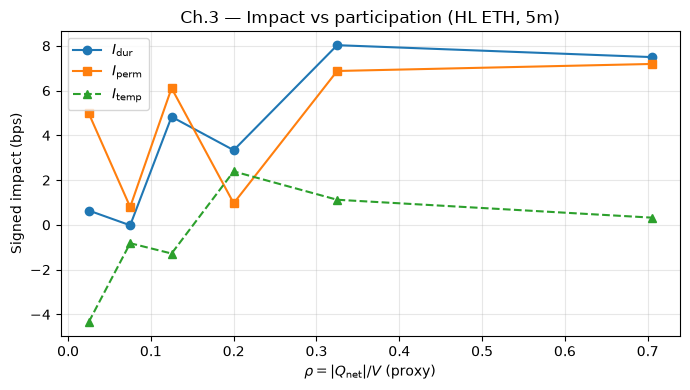

In [2]:
# Impact vs participation buckets (book Fig 3.4 analogue)
buckets = summary["buckets_5m"]
x = [0.5 * (b["rho_lo"] + b["rho_hi"]) for b in buckets]
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, [b["mean_I_dur_bps"] for b in buckets], "o-", label=r"$I_{\mathrm{dur}}$")
ax.plot(x, [b["mean_I_perm_bps"] for b in buckets], "s-", label=r"$I_{\mathrm{perm}}$")
ax.plot(x, [b["mean_I_temp_bps"] for b in buckets], "^--", label=r"$I_{\mathrm{temp}}$")
ax.set_xlabel(r"$\rho = |Q_{\mathrm{net}}|/V$ (proxy)")
ax.set_ylabel("Signed impact (bps)")
ax.set_title("Ch.3 — Impact vs participation (HL ETH, 5m)")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


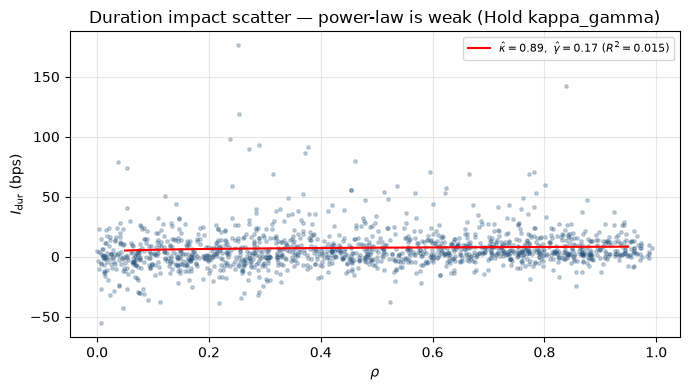

In [3]:
# Scatter + weak power-law guide
rho, I, sig = z["rho5"], z["I_dur5"], z["sigma5"]
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(rho, I, s=6, alpha=0.25, c="#1f4e79")
fit = summary["fit_5m"]
if fit.get("ok"):
    xs = np.linspace(0.05, 0.95, 60)
    sig_med = float(np.nanmedian(sig))
    ax.plot(xs, fit["kappa"] * sig_med * xs ** fit["gamma"], "r-",
            label=fr"$\hat\kappa={fit['kappa']:.2f},\ \hat\gamma={fit['gamma']:.2f}$ ($R^2={fit['r2']:.3f}$)")
    ax.legend(fontsize=8)
ax.set_xlabel(r"$\rho$"); ax.set_ylabel(r"$I_{\mathrm{dur}}$ (bps)")
ax.set_title("Duration impact scatter — power-law is weak (Hold kappa_gamma)")
ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


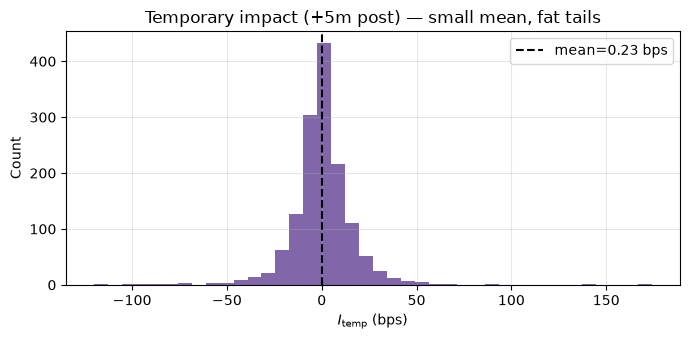

In [4]:
# Temporary impact distribution
temps = z["I_temp5"]; temps = temps[np.isfinite(temps)]
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(temps, bins=40, color="#6b4c9a", alpha=0.85)
ax.axvline(temps.mean(), color="k", ls="--", label=f"mean={temps.mean():.2f} bps")
ax.set_xlabel(r"$I_{\mathrm{temp}}$ (bps)"); ax.set_ylabel("Count")
ax.set_title("Temporary impact (+5m post) — small mean, fat tails")
ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


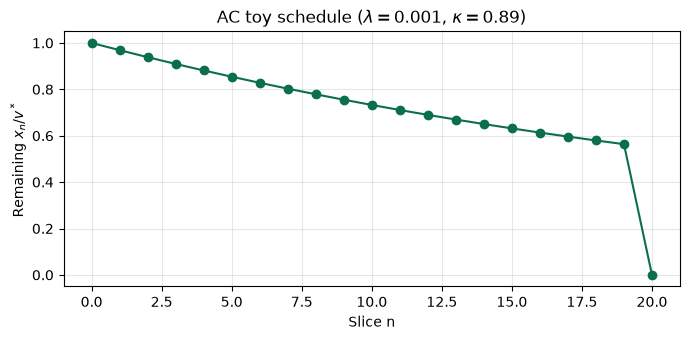

In [5]:
# Almgren–Chriss toy remaining-qty path (App A.6)
ac = summary["ac_toy"]
rem = np.asarray(ac["remaining"])
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(np.arange(len(rem)), rem, "o-", color="#0b6e4f")
ax.set_xlabel("Slice n"); ax.set_ylabel(r"Remaining $x_n/v^*$")
ax.set_title(fr"AC toy schedule ($\lambda={ac['lambda']}$, $\kappa={ac['kappa']:.2f}$)")
ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


## Promote / Hold / Kill (desk)

See `CANDIDATES.md` and `EXP_REPORT.md` in this folder.

**Blockers:** no proprietary fill tape for true IS/VWAP TCA; $\rho$ is not single-agent POV; power-law params not production-ready; extradial systematic/idiosyncratic split needs index beta (Kill here).


## Iterate — simulated single-algo POV + extraday sys/idio

Artifacts: `research/out/ch03_pov_idio/`. Script: `scripts/exp_ch03_pov_idio.py`.

- **Simulated POV:** parent horizon 1h, slice 1m, $\pi\in\{1,2,5,10,15,20\}\%$; fill@slice VWAP + book impact markup $\kappa\sigma\pi^{\gamma}$ ($\kappa=0.9$, $\gamma=0.5$).
- **Beta panel:** Deribit 1m marks BTC/ETH/SOL; $r_i=\alpha+\beta_i r_m+\varepsilon_i$.
- Honesty: **not** live TCA; tape $\rho$ remains flow intensity.


POV parents 2808 unique windows 234
Spearman(POV, I_model) 0.641
Spearman(tape ρ, |I_dur|) 0.054
by π:
  π=0.01  I_model=0.57 bps  |I_dur|=35.5
  π=0.02  I_model=0.81 bps  |I_dur|=35.5
  π=0.05  I_model=1.28 bps  |I_dur|=35.5
  π=0.10  I_model=1.81 bps  |I_dur|=35.5
  π=0.15  I_model=2.21 bps  |I_dur|=35.5
  π=0.20  I_model=2.55 bps  |I_dur|=35.5
ETH β=0.930 R²=0.672 sys/idio=0.67/0.33
SOL β=1.999 R²=0.709 sys/idio=0.71/0.29


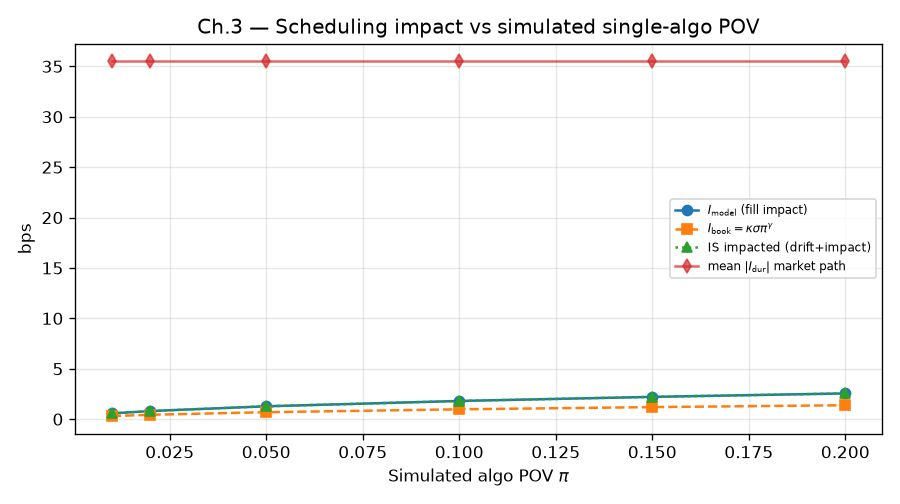

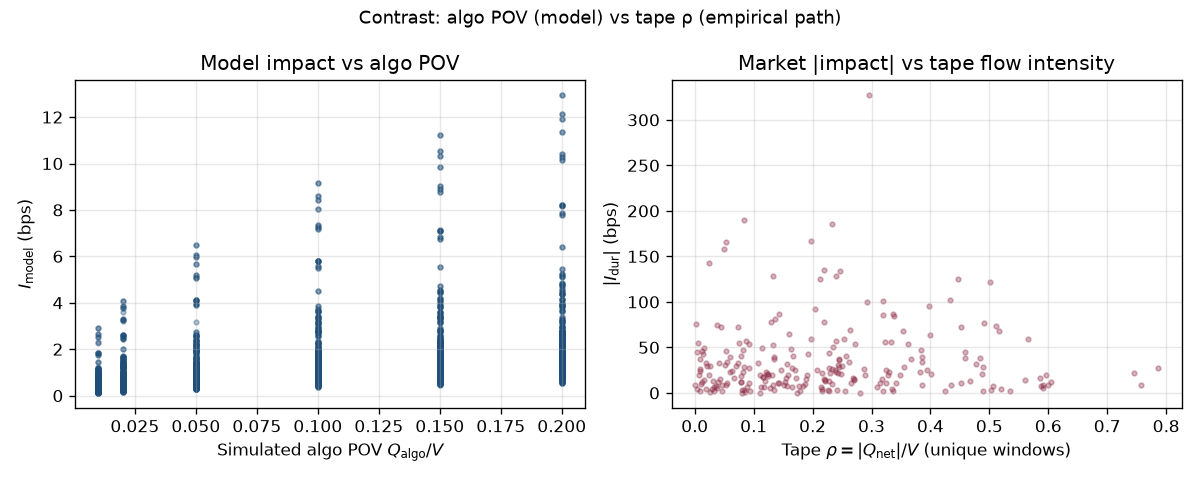

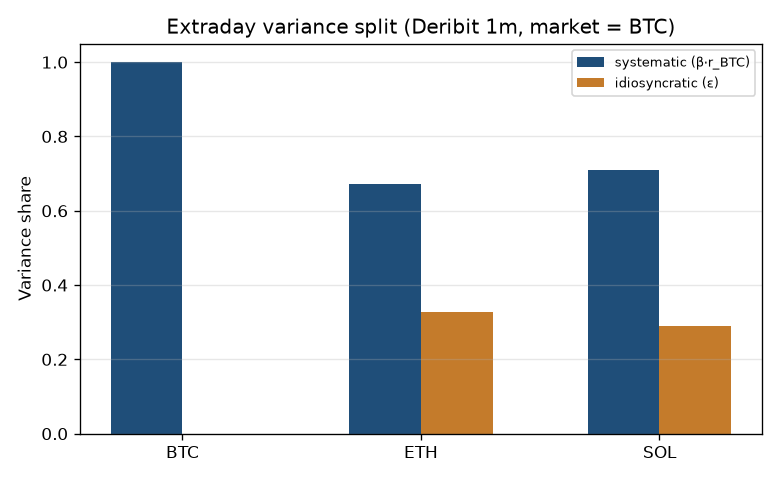

In [6]:
import json
from pathlib import Path
from IPython.display import Image, display

POV = Path('../../out/ch03_pov_idio')
summary = json.loads((POV / 'exp_ch03_pov_idio_summary.json').read_text())
print('POV parents', summary['pov']['n_parents'], 'unique windows', summary['pov']['n_unique_windows'])
print('Spearman(POV, I_model)', round(summary['pov']['spearman_pov_Imodel'], 3))
print('Spearman(tape ρ, |I_dur|)', round(summary['pov']['spearman_rho_absI'], 3))
print('by π:')
for b in summary['pov_by_pi']:
    print(f"  π={b['pi_target']:.2f}  I_model={b['mean_I_model_bps']:.2f} bps  |I_dur|={b['mean_abs_I_dur_bps']:.1f}")
eth = summary['beta_panel']['market_btc']['ETH']
sol = summary['beta_panel']['market_btc']['SOL']
print(f"ETH β={eth['beta']:.3f} R²={eth['r2']:.3f} sys/idio={eth['share_sys']:.2f}/{eth['share_idio']:.2f}")
print(f"SOL β={sol['beta']:.3f} R²={sol['r2']:.3f} sys/idio={sol['share_sys']:.2f}/{sol['share_idio']:.2f}")
for name in ['impact_vs_algo_pov.png', 'impact_pov_vs_tape_rho.png', 'beta_var_shares.png']:
    display(Image(filename=str(POV / name)))


### Decisions (iterate)

| id | decision | MM note |
|----|----------|--------|
| `impact.algo_pov_sim` | **Promote** | Scheduling / risk caps on *algo* π |
| `style.extraday_idio` | **Promote** | Minimal BTC/ETH/SOL panel; short sample |
| tape `impact.rho_slope` | **Promote** | Flow-intensity monitor only |
| own-fill TCA | **Hold** | Needs shadow / proprietary fills |
